# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2533s 15us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

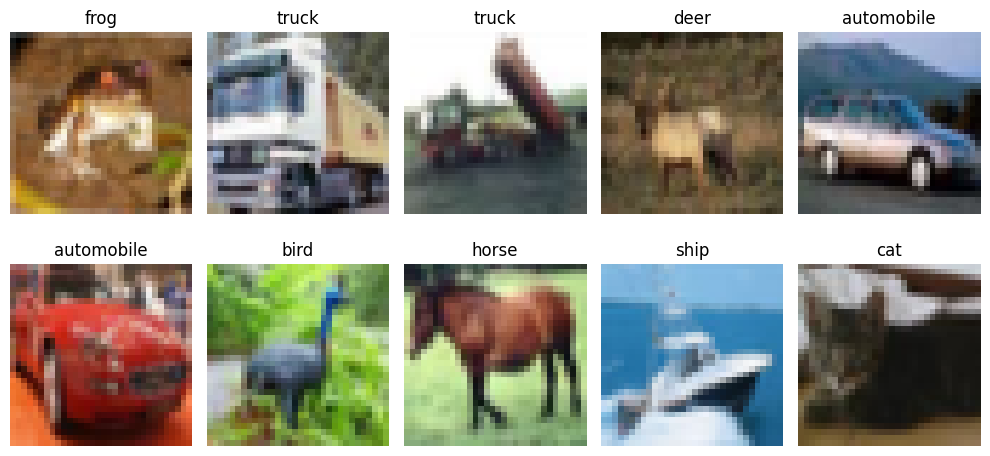

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.2691 - loss: 1.9991 - val_accuracy: 0.3238 - val_loss: 1.8513
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - accuracy: 0.3073 - loss: 1.8825 - val_accuracy: 0.3422 - val_loss: 1.8203
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.3327 - loss: 1.8248 - val_accuracy: 0.3490 - val_loss: 1.7870
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3474 - loss: 1.7907 - val_accuracy: 0.3594 - val_loss: 1.7699
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3584 - loss: 1.7608 - val_accuracy: 0.3722 - val_loss: 1.7194
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3657 - loss: 1.7390 - val_accuracy: 0.4174 - val_loss: 1.6971
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3753 - loss: 1.7172 - val_accuracy: 0.4260 - val_loss: 1.6608
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.3820 - loss: 1.7125 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4277 - loss: 1.6264
ANN Test Accuracy: 0.427700012922287


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 109ms/step - accuracy: 0.4794 - loss: 1.4738 - val_accuracy: 0.5092 - val_loss: 1.3858
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.6171 - loss: 1.1000 - val_accuracy: 0.6204 - val_loss: 1.0759
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.6776 - loss: 0.9340 - val_accuracy: 0.6708 - val_loss: 0.9439
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.7151 - loss: 0.8209 - val_accuracy: 0.6588 - val_loss: 1.0071
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.7445 - loss: 0.7306 - val_accuracy: 0.6988 - val_loss: 0.8769
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.7761 - loss: 0.6435 - val_accuracy: 0.7130 - val_loss: 0.8576
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.7965 - loss: 0.5781 - val_accuracy: 0.6788 - val_loss: 1.0582
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.8138 - loss: 0

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7042 - loss: 1.0373
CNN Test Accuracy: 0.704200029373169


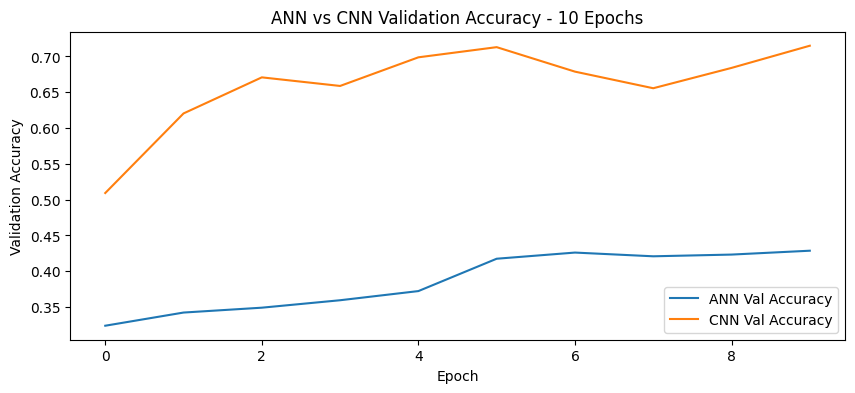

In [10]:
plt.figure(figsize=(10,4))

plt.plot(ann_history.history['val_accuracy'], label='ANN Val Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN Validation Accuracy - 10 Epochs")
plt.legend()
plt.show()

## 🧪 Beginner Task Experiments

In this section we improve the baseline models using:

- More ANN layers
- CNN filters (32 → 64 → 128)
- Training for 20 epochs
- EarlyStopping
- Data Augmentation

The goal is to observe how architecture and training strategies affect performance.

In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## 🔹 Improved ANN Model

The ANN architecture is expanded with additional hidden layers.

Expected Outcomes:
- Better feature learning
- Slight improvement in accuracy
- Still limited because image spatial information is lost

In [12]:
ann_model_2 = models.Sequential([
    layers.Input(shape=(3072,)),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_2 = ann_model_2.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.2430 - loss: 2.0380 - val_accuracy: 0.3226 - val_loss: 1.8867
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.2876 - loss: 1.9219 - val_accuracy: 0.3260 - val_loss: 1.8449
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3137 - loss: 1.8687 - val_accuracy: 0.3502 - val_loss: 1.7983
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3286 - loss: 1.8352 - val_accuracy: 0.3790 - val_loss: 1.7673
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3361 - loss: 1.8148 - val_accuracy: 0.3870 - val_loss: 1.7444
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3414 - loss: 1.7969 - val_accuracy: 0.3802 - val_loss: 1.7254
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3495 - loss: 1.7804 - val_accuracy: 0.3868 - val_loss: 1.7348
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3542 - loss: 1.7732 - 

In [13]:
ann2_loss, ann2_acc = ann_model_2.evaluate(
    x_test_flat,
    y_test
)

print("Improved ANN Accuracy:", ann2_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4135 - loss: 1.6646
Improved ANN Accuracy: 0.41350001096725464


## 🔹 Improved CNN

This CNN uses progressively larger filters:

32 Filters → Basic edges

64 Filters → Shapes and textures

128 Filters → Complex object parts

EarlyStopping prevents unnecessary training once validation performance stops improving.

In [14]:
cnn_model_2 = models.Sequential([

    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_2 = cnn_model_2.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 113ms/step - accuracy: 0.4812 - loss: 1.5471 - val_accuracy: 0.4454 - val_loss: 1.7898
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 111ms/step - accuracy: 0.6293 - loss: 1.0647 - val_accuracy: 0.5088 - val_loss: 1.5779
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 113ms/step - accuracy: 0.6822 - loss: 0.9017 - val_accuracy: 0.5970 - val_loss: 1.1233
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 113ms/step - accuracy: 0.7212 - loss: 0.7934 - val_accuracy: 0.6718 - val_loss: 0.9785
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 111ms/step - accuracy: 0.7527 - loss: 0.7045 - val_accuracy: 0.6810 - val_loss: 0.9640
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.7780 - loss: 0.6280 - val_accuracy: 0.6648 - val_loss: 1.0070
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 118ms/step - accuracy: 0.7975 - loss: 0.5680 - val_accuracy: 0.6848 - val_loss: 0.9712
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 112ms/step - accuracy: 0.8147 - loss: 

In [15]:
cnn2_loss, cnn2_acc = cnn_model_2.evaluate(
    x_test_norm,
    y_test
)

print("Improved CNN Accuracy:", cnn2_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6680 - loss: 0.9954
Improved CNN Accuracy: 0.6679999828338623


## CNN with Data Augmentation

Data augmentation creates modified versions of images during training.

Techniques Used:
- Horizontal Flip
- Rotation
- Zoom

Benefits:
- Reduces overfitting
- Improves generalization
- Makes the model robust to variations

In [16]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)

])

In [17]:
aug_cnn_model = models.Sequential([

    layers.Input(shape=(32,32,3)),

    data_augmentation,

    layers.Conv2D(32,3,activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 126ms/step - accuracy: 0.4111 - loss: 1.7176 - val_accuracy: 0.5296 - val_loss: 1.3242
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 127ms/step - accuracy: 0.5218 - loss: 1.3551 - val_accuracy: 0.5596 - val_loss: 1.2366
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 126ms/step - accuracy: 0.5673 - loss: 1.2306 - val_accuracy: 0.5858 - val_loss: 1.1841


In [18]:
aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5226 - loss: 1.3189
Augmented CNN Accuracy: 0.522599995136261


## 📈 Compare Learning Curves

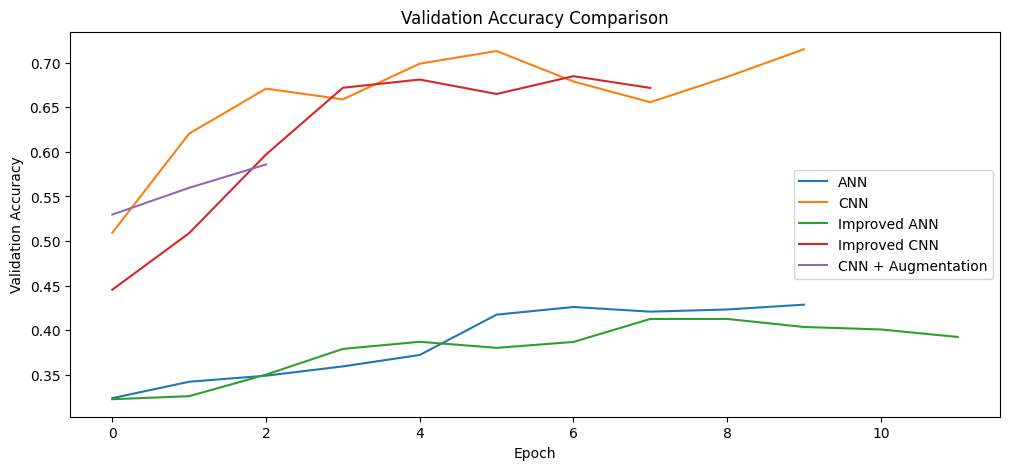

In [19]:
plt.figure(figsize=(12,5))

plt.plot(ann_history.history['val_accuracy'],label='ANN')

plt.plot(cnn_history.history['val_accuracy'],label='CNN')

plt.plot(ann_history_2.history['val_accuracy'],label='Improved ANN')

plt.plot(cnn_history_2.history['val_accuracy'],label='Improved CNN')

plt.plot(aug_history.history['val_accuracy'],label='CNN + Augmentation')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

# 📊 Final Comparison Table

In [20]:
comparison = pd.DataFrame({

    "Model":[
        "ANN",
        "CNN",
        "Improved ANN",
        "Improved CNN",
        "CNN + Augmentation"
    ],

    "Test Accuracy":[
        ann_test_acc,
        cnn_test_acc,
        ann2_acc,
        cnn2_acc,
        aug_acc
    ]
})

comparison["Test Accuracy"] = comparison["Test Accuracy"].round(4)

comparison

,Model,Test Accuracy
0,ANN,0.4277
1,CNN,0.7042
2,Improved ANN,0.4135
3,Improved CNN,0.6680
4,CNN + Augmentation,0.5226


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**